# Clasificación con Iris Dataset en PyTorch (MLP + Softmax)

In [1]:
import copy
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Semilla
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Datos

In [2]:
# Cargamos Iris
iris = load_iris()
X = iris['data'].astype(np.float32)   # shape (150, 4)
y = iris['target'].astype(np.int64)   # target {0,1,2}

In [3]:
# Train/validation split (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)

In [4]:
# Estandarizamos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)

X_train.shape, X_val.shape

((120, 4), (30, 4))

In [5]:
# Creamos los PyTorch datasets/loaders
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val))

train_batch_size = len(train_ds) # Full batch
val_batch_size = len(val_ds) # Full batch

train_loader = DataLoader(train_ds, batch_size=train_batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=val_batch_size, shuffle=False)

len(train_ds), len(val_ds)

(120, 30)

## Red Neuronal (Sesgo Inductivo) y Loss

In [6]:
# Definimos la red neuronal (Sesgo inductivo - Arquitectura de la red)
input_dim = X_train.shape[1]  # 4
hidden_dim = 2               # dimensión del hidden layer
num_classes = len(np.unique(y))  # 3

model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, num_classes)  # devuelve logits para CrossEntropyLoss
).to(device)

model

Sequential(
  (0): Linear(in_features=4, out_features=2, bias=True)
  (1): ReLU()
  (2): Linear(in_features=2, out_features=3, bias=True)
)

In [7]:
# Para uso posterior
init_state = copy.deepcopy(model.state_dict())

In [8]:
from torchsummary import summary
summary(model, input_size=(4,))  # batch_size=16, input_dim=4

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                    [-1, 2]              10
              ReLU-2                    [-1, 2]               0
            Linear-3                    [-1, 3]               9
Total params: 19
Trainable params: 19
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [9]:
!pip install torchinfo

In [10]:
from torchinfo import summary
summary(model, input_size=(train_batch_size, 4))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [120, 3]                  --
├─Linear: 1-1                            [120, 2]                  10
├─ReLU: 1-2                              [120, 2]                  --
├─Linear: 1-3                            [120, 3]                  9
Total params: 19
Trainable params: 19
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01

In [11]:
!pip install torchviz

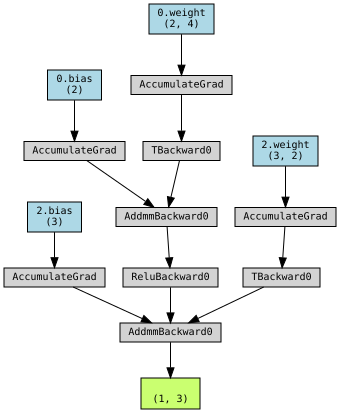

In [12]:
from torchviz import make_dot
x = torch.randn(1, 4).to(device)
y = model(x)
make_dot(y, params=dict(model.named_parameters()))

## Explicación del grafo

### **Nodos azules (parámetros del modelo)**

* `0.weight (2,4)`: la matriz de pesos de la primera capa lineal (`nn.Linear(4,2)` en tu red). Dimensiones: 2 neuronas × 4 entradas.
* `0.bias (2)`: el vector de bias asociado a esa capa (2 entradas).
* `2.weight (3,2)`: la matriz de pesos de la segunda capa lineal (`nn.Linear(2,3)`). Dimensiones: 3 salidas × 2 entradas.
* `2.bias (3)`: bias de la segunda capa (3 entradas).

👉 Estos nodos alimentan el grafo hacia abajo: se usan en multiplicaciones y sumas.

---

### **Nodos grises (operaciones / funciones autograd)**

* `AccumulateGrad`: PyTorch crea uno de estos para cada parámetro entrenable. Es el nodo que acumula los gradientes durante el *backward*.
* `TBackward0`: representa la transposición de un tensor (se usa en el cálculo del gradiente de una multiplicación matricial).
* `AddmmBackward0`: corresponde a la operación **linear = X·Wᵀ + b** (matrix multiply más bias). Hay dos:

  * El primero combina `0.weight` y `0.bias` para dar la salida de la capa 1.
  * El segundo combina `2.weight` y `2.bias` para la capa 2.
* `ReluBackward0`: el backward de la activación ReLU aplicada entre las dos capas.

---

### **Nodo verde (salida final)**

* `(1,3)`: la salida de tu red para un batch de tamaño 1 y 3 clases posibles. Este tensor es el resultado de la última capa lineal (los *logits*).

In [13]:
# La función de loss
criterion = nn.CrossEntropyLoss()

## Algoritmo de optimización

### Pseudocódigo: SGD.step() (un solo tensor de parámetros θ)

**Hiperparámetros:**
*   η : learning rate
*   μ : momentum ∈ [0,1)
*   τ : dampening ∈ [0,1]
*   λ : weight_decay (L2 acoplado) ≥ 0
*   nesterov : bool

**Estado persistente entre steps:**
   
   v : buffer de momento (mismo tamaño que θ) o None si no existe aún

**Entradas del paso:**
*   θ : tensor de parámetros
*   g : gradiente actual del costo en θ (g = ∇J(θ))
*   v : buffer de momento previo (o None la primera vez)
*   η, μ, τ, λ, nesterov

1.      Dirección base

        d ← g

2.      L2 acoplado (weight decay): sumar λ·θ a la dirección si λ > 0:
    
        d ← d + λ·θ

3.      Momento
    
        if μ > 0:
        
            if v es None:
                # primer uso: arrancar el buffer sin amortiguación
                v ← d
            else:
                v ← μ·v + (1 − τ)·d

            Nesterov: "look-ahead"
    
            if nesterov:
        
                d_eff ← d + μ·v
    
        else:
        
            d_eff ← v

        else:
        
            d_eff ← d

4.      Paso de optimización (descenso)

        θ ← θ − η·d_eff

**Salida del paso:**
*   parámetros actualizados θ
*   estado actualizado v

In [14]:
# Parámetros para Gradient Descent
lr = 0.02 # learning rate
optimizer = torch.optim.SGD(
    params = model.parameters(),
    lr=lr,
    momentum=0,
    dampening=0,
    weight_decay=0,
    nesterov=False
    )

In [15]:
def run_epoch(dataloader, model, criterion, optimizer=None):
    # Corre una epoch. Si optimizer es None solo hace evaluación.
    if optimizer is None:
        model.eval()
        torch.set_grad_enabled(False)
    else:
        model.train()
        torch.set_grad_enabled(True)

    total_loss = 0.0
    total_items = 0
    correct = 0

    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)

        if optimizer is not None:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if optimizer is not None:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_items += xb.size(0)

        preds = torch.argmax(logits, dim=1)
        correct += (preds == yb).sum().item()

    avg_loss = total_loss / total_items
    accuracy = correct / total_items
    return avg_loss, accuracy

In [16]:
epochs = 10000
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, criterion, optimizer=None)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | "
              f"train loss {tr_loss:.4f}, val loss {val_loss:.4f} | "
              f"train acc {tr_acc:.3f}, val acc {val_acc:.3f}")

Epoch   1 | train loss 1.2315, val loss 1.2195 | train acc 0.333, val acc 0.333
Epoch 200 | train loss 0.8283, val loss 0.8518 | train acc 0.683, val acc 0.667
Epoch 400 | train loss 0.6618, val loss 0.6921 | train acc 0.808, val acc 0.700
Epoch 600 | train loss 0.5491, val loss 0.5930 | train acc 0.842, val acc 0.733
Epoch 800 | train loss 0.4647, val loss 0.5106 | train acc 0.892, val acc 0.767
Epoch 1000 | train loss 0.4072, val loss 0.4513 | train acc 0.900, val acc 0.867
Epoch 1200 | train loss 0.3654, val loss 0.4094 | train acc 0.917, val acc 0.933
Epoch 1400 | train loss 0.3330, val loss 0.3776 | train acc 0.925, val acc 0.933
Epoch 1600 | train loss 0.3068, val loss 0.3520 | train acc 0.933, val acc 0.967
Epoch 1800 | train loss 0.2850, val loss 0.3304 | train acc 0.933, val acc 0.967
Epoch 2000 | train loss 0.2664, val loss 0.3118 | train acc 0.967, val acc 0.967
Epoch 2200 | train loss 0.2504, val loss 0.2953 | train acc 0.967, val acc 0.967
Epoch 2400 | train loss 0.2364, v

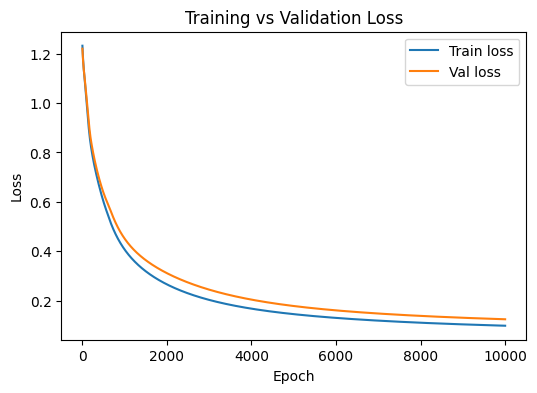

In [17]:
# Plot training and validation loss vs epochs
plt.figure(figsize=(6,4))
plt.plot(range(1, epochs+1), train_losses, label="Train loss")
plt.plot(range(1, epochs+1), val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [18]:
print(f"Accuracy final en Val: {val_accs[-1]:.3f}")

# Ejemplo: obtener softmax de las primeras 5 filas
model.eval()
with torch.no_grad():
    xb = torch.from_numpy(X_val[:5]).to(device)
    logits = model(xb)
    probs = torch.softmax(logits, dim=1).cpu().numpy()

print("Softmax (1eras 5 filas):")
print(np.round(probs, 3))

Accuracy final en Val: 0.967
Softmax (1eras 5 filas):
[[0.965 0.035 0.   ]
 [0.    0.298 0.702]
 [0.103 0.893 0.005]
 [0.056 0.939 0.006]
 [0.965 0.035 0.   ]]


# Grafico del Costo Empírico

In [19]:
from mpl_toolkits.mplot3d import Axes3D

In [20]:
model.eval()
Xtr = torch.from_numpy(X_train).to(device)
ytr = torch.from_numpy(y_train).to(device)

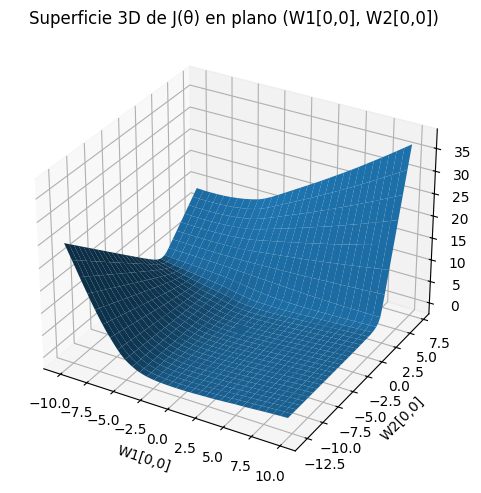

<All keys matched successfully>

In [21]:
# ==== Superficie 3D de J(θ): promedio sobre todo el train, variables = 2 parámetros ====

# --- Elegir dos parámetros escalares (puedes cambiar estos índices) ---
p1 = model[0].weight    # tensor (2,4) de la 1ª capa
idx1 = (0, 0)
label1 = "W1[0,0]"

p2 = model[2].weight    # tensor (3,2) de la 2ª capa
idx2 = (0, 0)
label2 = "W2[0,0]"

# λ desde el optimizer (si no existe, se asume 0)
lam = float(optimizer.param_groups[0].get("weight_decay", 0.0))

# Backup por seguridad (aunque restauramos en cada evaluación)
_state = copy.deepcopy(model.state_dict())

@torch.no_grad()
def empirical_risk(val1, val2, include_weight_decay=True):
    """
    L(θ) = (1/N) * sum_i CE(f_θ(x_i), y_i)  [+ (λ/2)||θ||^2 si include_weight_decay]
    Variando sólo p1[idx1] y p2[idx2], manteniendo el resto de θ fijo.
    """
    old1 = p1.data[idx1].item()
    old2 = p2.data[idx2].item()
    try:
        p1.data[idx1] = val1
        p2.data[idx2] = val2
        logits = model(Xtr)
        data_loss = criterion(logits, ytr).item()  # CrossEntropyLoss por defecto es promedio
        if include_weight_decay and lam > 0:
            sqnorm = 0.0
            for q in model.parameters():
                sqnorm += float(q.detach().pow(2).sum().cpu().item())
            reg = 0.5 * lam * sqnorm   # L2 acoplado: (λ/2)||θ||^2
            return data_loss + reg
        else:
            return data_loss
    finally:
        # restaurar valores para no “arrastrar” cambios durante el barrido
        p1.data[idx1] = old1
        p2.data[idx2] = old2

# Centro del plano = valores actuales
w1_0 = p1.data[idx1].item()
w2_0 = p2.data[idx2].item()

# Rango del grid
def _span_from(t, default=0.5):
    s = float(t.data.std().cpu().item())
    return max(default, 3.0*s)

span1 = _span_from(p1, default=10)
span2 = _span_from(p2, default=10)

N = 61  # densidad del grid
w1_vals = np.linspace(w1_0 - span1, w1_0 + span1, N)
w2_vals = np.linspace(w2_0 - span2, w2_0 + span2, N)

Z = np.empty((N, N), dtype=np.float32)
for i, a in enumerate(w1_vals):
    for j, b in enumerate(w2_vals):
        Z[j, i] = empirical_risk(float(a), float(b), include_weight_decay=True)

# Plot 3D
Xg, Yg = np.meshgrid(w1_vals, w2_vals)
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(Xg, Yg, Z, linewidth=0, antialiased=True)

# Punto actual
z0 = empirical_risk(w1_0, w2_0, include_weight_decay=True)
ax.scatter([w1_0], [w2_0], [z0], s=40)

ax.set_xlabel(label1)
ax.set_ylabel(label2)
ax.set_zlabel("Costo J(θ)")
ax.set_title(f"Superficie 3D de J(θ) en plano ({label1}, {label2})")
plt.tight_layout()
plt.show()

# Restaurar (por si acaso)
model.load_state_dict(_state)


# Gráfico de la trayectoria

In [22]:
model.load_state_dict(init_state)        # restaura pesos/bias iniciales
optimizer = torch.optim.SGD(             # reinicia el optimizador (y su estado)
    model.parameters(), lr=lr, momentum=0, dampening=0, weight_decay=0, nesterov=False
)

In [23]:
# Elegir dos parámetros a proyectar
idx1 = (0, 0); label1 = "W1[0,0]"   # de Linear(4->2)
idx2 = (0, 0); label2 = "W2[0,0]"   # de Linear(2->3)

# lambda del weight-decay
lam = float(optimizer.param_groups[0].get("weight_decay", 0.0))

In [24]:
# Paisaje: modelo "congelado" en θ0 (init_state)
land = copy.deepcopy(model).to(device)
land.load_state_dict(init_state)
land.eval()
p1L = land[0].weight
p2L = land[2].weight

In [25]:
# Datos full-batch en el device actual
Xtr = torch.from_numpy(X_train).to(device)
ytr = torch.from_numpy(y_train).to(device)

In [26]:
@torch.no_grad()
def risk_land(a, b, include_weight_decay=True):
    old1, old2 = p1L.data[idx1].item(), p2L.data[idx2].item()
    try:
        p1L.data[idx1] = float(a)
        p2L.data[idx2] = float(b)
        logits = land(Xtr)
        L = criterion(logits, ytr).item()  # promedio sobre todo el train
        if include_weight_decay and lam > 0:
            sn = 0.0
            for q in land.parameters():
                sn += float(q.detach().pow(2).sum().cpu().item())
            L += 0.5 * lam * sn
        return L
    finally:
        p1L.data[idx1] = old1
        p2L.data[idx2] = old2

In [27]:
# Valores actuales (centro del plano)
w1_0 = p1.data[idx1].item()
w2_0 = p2.data[idx2].item()

In [28]:
# Escalas para el rango del grid (automáticas, pero podés ajustarlas)
def _span_from(tensor, default=1.0):
    s = float(tensor.data.std().cpu().item())
    return max(default, 3.0*s)

In [29]:
span1 = _span_from(p1L, default=1.0)
span2 = _span_from(p2L, default=1.0)
N = 81
w1_vals = np.linspace(w1_0 - span1, w1_0 + span1, N)
w2_vals = np.linspace(w2_0 - span2, w2_0 + span2, N)

Z = np.empty((N, N), dtype=np.float32)
for i, a in enumerate(w1_vals):
    for j, b in enumerate(w2_vals):
        Z[j, i] = risk_land(a, b, include_weight_decay=True)

In [30]:
torch.set_grad_enabled(True)

traj = copy.deepcopy(model).to(device)
traj.load_state_dict(init_state)   # empezar exactamente en θ0
traj.train()

# usar los mismos hiperparámetros que definiste
opt_traj = torch.optim.SGD(
    traj.parameters(),
    lr=lr,
    momentum=optimizer.param_groups[0].get("momentum", 0.0),
    dampening=optimizer.param_groups[0].get("dampening", 0.0),
    weight_decay=lam,
    nesterov=optimizer.param_groups[0].get("nesterov", False),
)

coords = []
steps = 200  # pasos de SGD para dibujar
for t in range(steps):
    opt_traj.zero_grad(set_to_none=True)
    out = traj(Xtr)
    loss = criterion(out, ytr)
    loss.backward()
    opt_traj.step()

    # proyectar θ_t a las 2 coordenadas elegidas
    p1t = traj[0].weight.data[idx1].item()
    p2t = traj[2].weight.data[idx2].item()
    coords.append((p1t, p2t))

coords = np.array(coords)

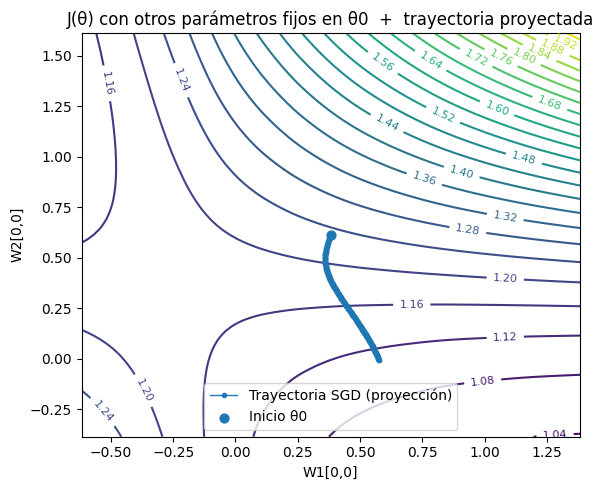

In [32]:
# Gráfico: curvas de nivel (paisaje en θ0) + trayectoria proyectada
Xg, Yg = np.meshgrid(w1_vals, w2_vals)
plt.figure(figsize=(6,5))
CS = plt.contour(Xg, Yg, Z, levels=25)
plt.clabel(CS, inline=True, fontsize=8)

plt.plot(coords[:,0], coords[:,1], marker='o', markersize=3, linewidth=1, label="Trayectoria SGD (proyección)")
plt.scatter([w1_0], [w2_0], s=40, label="Inicio θ0")
plt.xlabel(label1); plt.ylabel(label2)
plt.title(f"J(θ) con otros parámetros fijos en θ0  +  trayectoria proyectada")
plt.legend()
plt.tight_layout()
plt.show()